In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/refs/heads/master/monthly-airline-passengers.csv"

df = pd.read_csv(url, usecols=[1])

data = df.values.astype("float32")

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)


In [4]:
SEQ_LENGTH = 10

X = np.array([
    data_scaled[i:i + SEQ_LENGTH]
    for i in range(len(data_scaled) - SEQ_LENGTH)
])

y = np.array([
    data_scaled[i + SEQ_LENGTH]
    for i in range(len(data_scaled) - SEQ_LENGTH)
])


In [5]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]


# Step 5: Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)

X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)

In [6]:
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=16,
    shuffle=True
)


In [7]:
class BiRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super(BiRNN, self).__init__()

        self.rnn = nn.RNN(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


In [8]:
class FeedforwardNN(nn.Module):
    def __init__(self, input_size):
        super(FeedforwardNN, self).__init__()

        self.fc1 = nn.Linear(input_size, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc2(self.relu(self.fc1(x)))

In [9]:
def train_model(model, loader, epochs=100):

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    model.train()

    for epoch in range(epochs):

        loss_epoch = 0

        for seqs, targets in loader:

            optimizer.zero_grad()

            outputs = model(seqs)

            loss = criterion(outputs, targets)

            loss.backward()

            optimizer.step()

            loss_epoch += loss.item()

        if (epoch + 1) % 20 == 0:
            print(
                f"Epoch {epoch + 1}/{epochs}, "
                f"Loss: {loss_epoch / len(loader):.5f}"
            )


In [10]:
def evaluate_model(model, X):

    model.eval()

    with torch.no_grad():
        return model(X).numpy()


In [11]:
print("Training Bidirectional RNN...")

birnn = BiRNN()
train_model(birnn, train_loader)

Training Bidirectional RNN...
Epoch 20/100, Loss: 0.00200
Epoch 40/100, Loss: 0.00219
Epoch 60/100, Loss: 0.00203
Epoch 80/100, Loss: 0.00237
Epoch 100/100, Loss: 0.00235


In [12]:
print("\nTraining Feedforward Neural Network...")

ffnn = FeedforwardNN(input_size=SEQ_LENGTH)
train_model(ffnn, train_loader)



Training Feedforward Neural Network...
Epoch 20/100, Loss: 0.00378
Epoch 40/100, Loss: 0.00138
Epoch 60/100, Loss: 0.00146
Epoch 80/100, Loss: 0.00112
Epoch 100/100, Loss: 0.00061


In [13]:
pred_birnn = evaluate_model(birnn, X_test_tensor)
pred_ffnn = evaluate_model(ffnn, X_test_tensor)


In [14]:
pred_birnn_inv = scaler.inverse_transform(pred_birnn)
pred_ffnn_inv = scaler.inverse_transform(pred_ffnn)

y_test_inv = scaler.inverse_transform(y_test)


In [15]:
mse_birnn = mean_squared_error(y_test_inv, pred_birnn_inv)
mse_ffnn = mean_squared_error(y_test_inv, pred_ffnn_inv)


In [16]:
print("\nPerformance Comparison")
print("----------------------")
print(f"BiRNN MSE: {mse_birnn:.3f}")
print(f"FFNN MSE: {mse_ffnn:.3f}")


Performance Comparison
----------------------
BiRNN MSE: 2631.998
FFNN MSE: 425.067


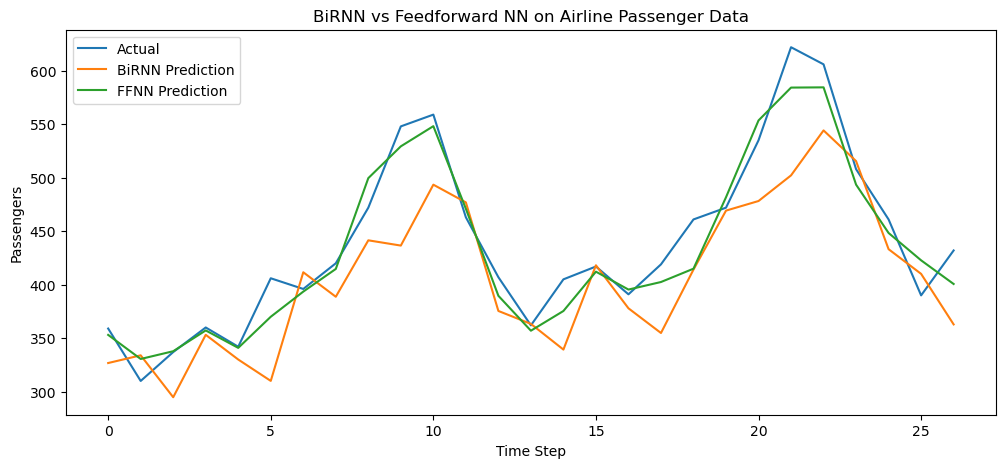

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(y_test_inv, label="Actual")
plt.plot(pred_birnn_inv, label="BiRNN Prediction")
plt.plot(pred_ffnn_inv, label="FFNN Prediction")

plt.title("BiRNN vs Feedforward NN on Airline Passenger Data")
plt.xlabel("Time Step")
plt.ylabel("Passengers")
plt.legend()
plt.show()